In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from scipy.integrate import solve_ivp

# Question 1

In [3]:
# c = x + iy
x = np.linspace(-2, 2, 1000)
y = np.linspace(-2, 2, 1000)
X,Y = np.meshgrid(x,y)
c = X + 1j * Y

In [4]:
from convergence import convergence

Plot as black and white graph for convergence and divergence

<function matplotlib.pyplot.show(close=None, block=None)>

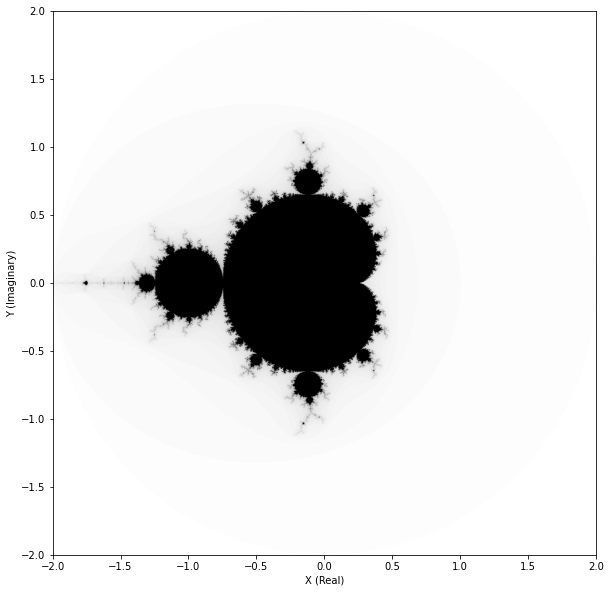

In [5]:
plt.figure(figsize=(10,10))
plt.imshow(convergence(c, 100), cmap="binary", extent=(-2, 2, -2, 2))
plt.xlabel("X (Real)")
plt.ylabel("Y (Imaginary)")
plt.show

Plot as coloured contour map to show point of divergence

<function matplotlib.pyplot.show(close=None, block=None)>

<Figure size 720x720 with 0 Axes>

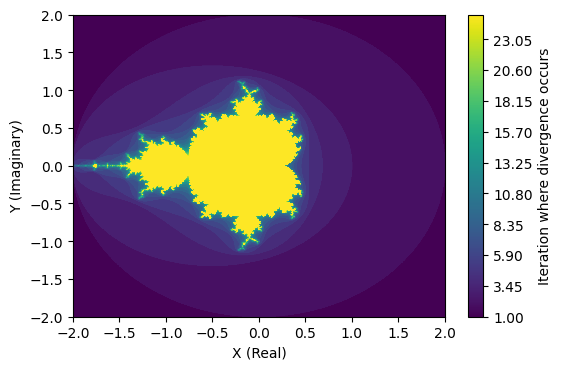

In [11]:
plt.figure(figsize=(10,10))
plt.figure(dpi=100)
plt.contourf(X, Y, convergence(c, 25), levels=500)
plt.colorbar(label="Iteration where divergence occurs")
plt.xlabel("X (Real)")
plt.ylabel("Y (Imaginary)")
plt.show

# Question 2

Part 1

In [14]:
def lorenz(t, W, sigma, r, b):
    """Finds the derivative of X according the the Lorenz equation 
    X dot = - sigma (X - Y)
    Y dot = rX - Y - XZ
    Z dot = - bZ + XY
    
    Parameters
    X, Y, Z: float
        Parameters described by the Lorenz equations
    sigma: float
        Prandtl number - ratio of kinematic viscosity to the thermal diffusivity
    r: float
        Rayleigh number 
    b: float
        
    Returns
        Z dot
    """
    return (- sigma * (W[0] - W[1]), r * W[0] - W[1] - W[0] * W[2], - b * W[2] + W[0] * W[1])

Part 2

In [15]:
# Set initial values
sigma = 10.0
r = 28
b = 8.0/3.0
W0 = (0.0, 1.0, 0.0)

In [16]:
t = np.linspace(0,60,6000)
sol = solve_ivp(lorenz, [0,60], W0, args=(sigma, r, b), t_eval = t)

Part 3 - Lorenz Figure 1

<function matplotlib.pyplot.show(close=None, block=None)>

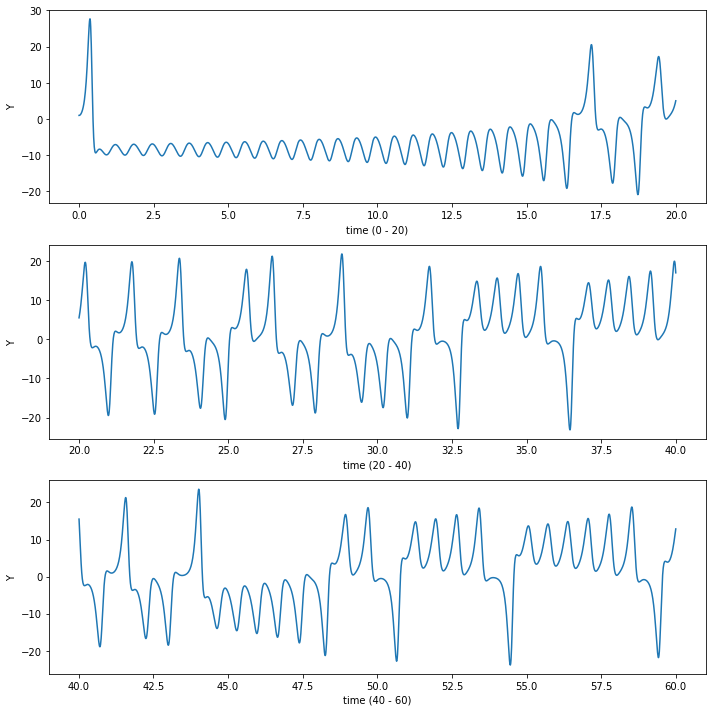

In [17]:
fig1, ax1 = plt.subplots(3,1, figsize=(10,10))

ax1[0].plot(sol.t[0:2000], sol.y[1][0:2000])
ax1[0].set_xlabel("time (0 - 20)")
ax1[0].set_ylabel("Y")

ax1[1].plot(sol.t[2000:4000], sol.y[1][2000:4000])
ax1[1].set_xlabel("time (20 - 40)")
ax1[1].set_ylabel("Y")

ax1[2].plot(sol.t[4000:6000], sol.y[1][4000:6000])
ax1[2].set_xlabel("time (40 - 60)")
ax1[2].set_ylabel("Y")

fig1.tight_layout()

plt.show

Part 4 - Lorenz Figure 2

<function matplotlib.pyplot.show(close=None, block=None)>

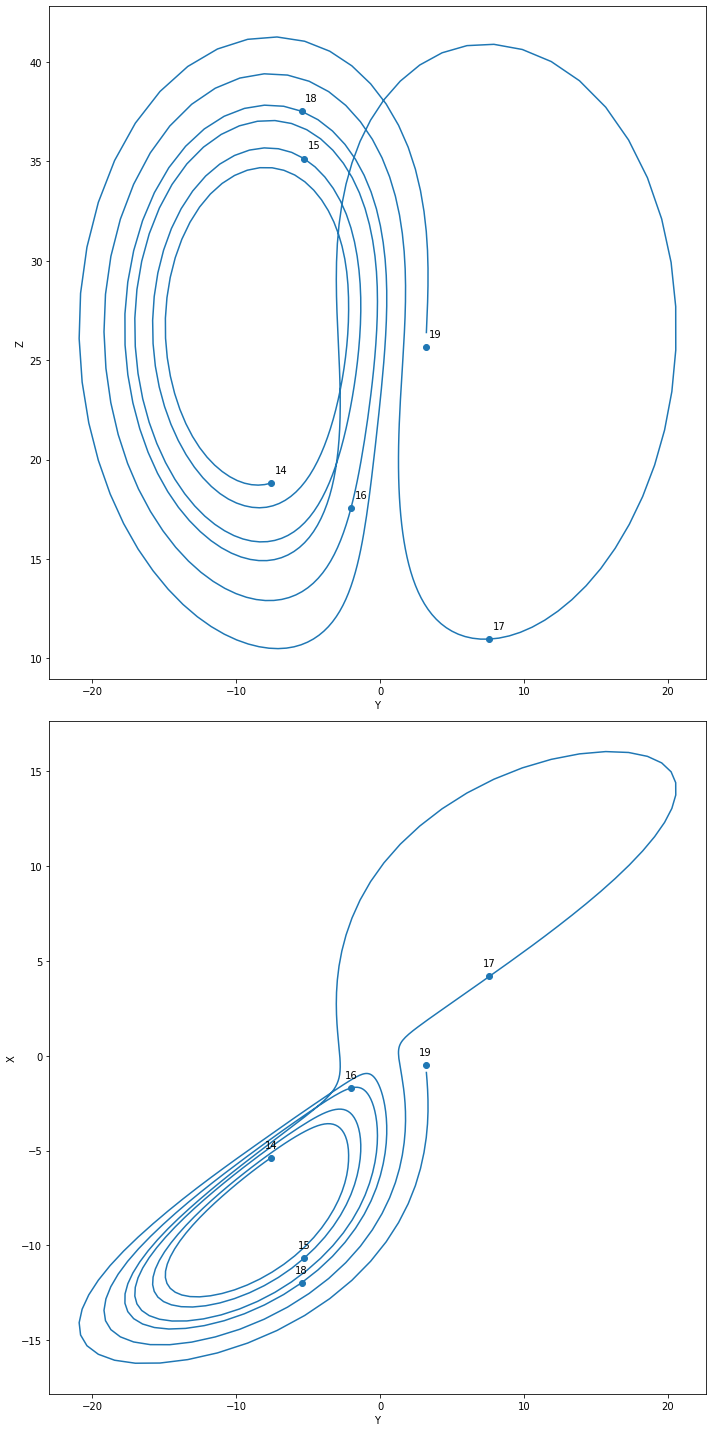

In [11]:
labels = np.array([14,15,16,17,18,19])
label_loc = np.array([1400,1500,1600,1700,1800,1900])

fig2, ax2 = plt.subplots(2,1, figsize = (10,20))

ax2[0].plot(sol.y[1][1400:1900], sol.y[2][1400:1900])
ax2[0].scatter(sol.y[1][label_loc], sol.y[2][label_loc])
ax2[0].set_xlabel("Y")
ax2[0].set_ylabel("Z")

ax2[1].plot(sol.y[1][1400:1900], sol.y[0][1400:1900])
ax2[1].scatter(sol.y[1][label_loc], sol.y[0][label_loc])
ax2[1].set_xlabel("Y")
ax2[1].set_ylabel("X")

for i, label in enumerate(labels):
    ax2[0].annotate(
        label,
        (sol.y[1][(14+i)*100], sol.y[2][(14+i)*100]),
        textcoords="offset points", 
        xytext=(10, 10),
        ha='center'
    )
    ax2[1].annotate(
        label,
        (sol.y[1][(14+i)*100], sol.y[0][(14+i)*100]),
        textcoords="offset points", 
        xytext=(0, 10),
        ha='center'                 
    )

fig2.tight_layout()

plt.show

Part 5

In [12]:
Wnew = W0 + np.array([0.0,1.0e-8,0])
solnew = solve_ivp(lorenz, [0,60], Wnew, args=(sigma, r, b),t_eval = t)

<function matplotlib.pyplot.show(close=None, block=None)>

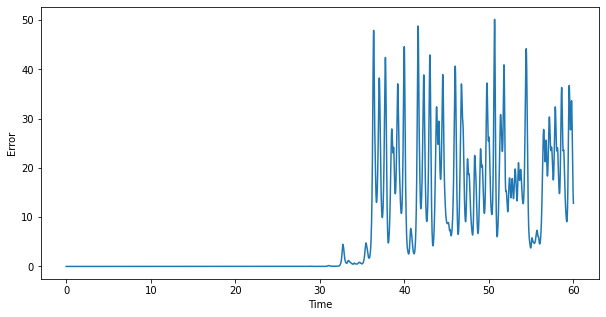

In [13]:
diff = solnew.y-sol.y
abs_diff = (diff[0]**2 + diff[1]**2 + diff[2]**2)**0.5
plt.figure(figsize = (10,5))
plt.plot(solnew.t, abs_diff)
plt.xlabel("Time")
plt.ylabel("Error")
plt.show